In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import time
import os
from joblib import dump, load

# Métricas e ferramentas de Machine Learning
import xgboost as xgb
import shap
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from collections import Counter
from scipy.spatial.distance import cdist
from sklearn.metrics import (accuracy_score,ConfusionMatrixDisplay,precision_score,recall_score,f1_score,roc_auc_score,roc_curve,confusion_matrix,classification_report,
                             precision_recall_curve,average_precision_score)

dados = pd.read_csv ("../Databases/base_treino_boruta.csv", sep=',')
dados

c:\Users\cassi\miniconda3\envs\cancer_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,sample_id,MIMAT0000070,MIMAT0000103,MIMAT0003240,MIMAT0004592,MIMAT0004602,MIMAT0004804,MIMAT0005586,MIMAT0007347,MIMAT0016849,...,MIMAT0027478,MIMAT0027498,MIMAT0027540,MIMAT0027574,MIMAT0027575,MIMAT0027660,MIMAT0027686,MIMAT0031000,target,split
0,GSM2278615,1.030720,1.152392,-0.321811,-0.388305,-0.632559,-0.006389,-0.173028,0.734924,-0.538253,...,0.558312,0.682544,-0.281433,-0.152731,-0.136623,0.091852,-0.503763,1.053621,1,train
1,GSM2278616,1.773204,0.953377,-0.173949,-0.473914,-0.558560,0.032618,0.436156,0.842601,-0.515910,...,2.327494,0.270474,-1.432550,0.126085,1.908569,-0.476252,-0.810687,0.903694,1,train
2,GSM2278617,0.684740,0.403192,-0.496596,-0.608497,-0.066235,-1.190762,2.336523,0.121293,-0.042676,...,0.379008,0.212516,-0.912393,2.028289,-0.133262,-1.409829,-0.114039,0.013329,1,train
3,GSM2278618,-0.794088,-1.039456,-0.325646,-0.392525,-0.382181,-0.085807,0.056988,1.684487,-0.236236,...,1.159776,-0.186710,-1.223107,0.149769,-0.128983,-1.642710,0.321930,0.527365,1,train
4,GSM2278619,-1.453257,-0.910481,-0.491062,-0.424341,-0.479572,-0.036304,0.178505,0.631550,-0.728127,...,-0.839302,-0.348432,-0.809020,0.294022,0.486672,-1.282433,-1.035871,0.367641,1,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,GSM1447837,1.328089,0.849867,1.410876,2.054690,1.477953,1.944974,-0.440131,-0.042935,-0.007901,...,-0.860789,-0.101230,0.246102,-0.030673,-1.283171,1.365195,0.346937,-0.132385,0,train
281,GSM1447839,-1.429717,-1.267393,1.671507,2.089174,1.935565,-0.035735,0.167215,-0.624830,0.249774,...,-1.316962,1.582785,1.226486,-3.219079,-1.514643,2.006021,1.122274,-2.233914,0,train
282,GSM1447840,-0.345422,-0.366692,1.147987,1.722085,1.612545,0.596328,-0.269979,-1.103681,0.572284,...,-0.574166,-0.939608,2.324517,-1.450733,-0.072031,0.567534,1.845342,-0.367161,0,train
283,GSM1447841,-0.365179,-1.267393,0.078382,1.693163,1.418407,0.877449,-1.697361,-0.624830,0.445940,...,0.511769,-0.565786,0.997730,-1.529889,0.126708,0.120642,1.411211,1.093030,0,train


In [30]:
# normalizar
# remover colunas que não são features
dados_num = dados.drop(columns=["sample_id", "target", "split"])

# target (0/1) separado como categorico
dados_cat = dados[["target"]]

# Instanciar o objeto normalizador
normalizador = preprocessing.MinMaxScaler()

# treinar o normalizador apenas nas features
modelo_normalizador_num = normalizador.fit(dados_num)

# salvando modelo normalizador
dump(modelo_normalizador_num, open("models_Tree_XGBoost/normalizador_TCC_Tree_XGBoost.model","wb"))

# normalizar atributos numéricos
dados_num_normalizado = modelo_normalizador_num.transform(dados_num)

# converter de volta para DataFrame
dados_num_df = pd.DataFrame(dados_num_normalizado, columns=dados_num.columns)

# juntar target (0/1) e split
dados_final = dados_num_df.join(dados_cat).join(dados[["split"]])
dados_final

,MIMAT0000070,MIMAT0000103,MIMAT0003240,MIMAT0004592,MIMAT0004602,MIMAT0004804,MIMAT0005586,MIMAT0007347,MIMAT0016849,MIMAT0018192,...,MIMAT0027478,MIMAT0027498,MIMAT0027540,MIMAT0027574,MIMAT0027575,MIMAT0027660,MIMAT0027686,MIMAT0031000,target,split
0,0.642643,0.556037,0.507214,0.198630,0.352515,0.568801,0.397176,0.449194,0.413662,0.444543,...,0.624663,0.630741,0.442053,0.527822,0.615689,0.483571,0.342527,0.473657,1,train
1,0.773114,0.515801,0.533194,0.175908,0.368558,0.574554,0.508098,0.465468,0.418135,0.570501,...,0.934508,0.569896,0.242716,0.575816,0.936687,0.406730,0.288510,0.452056,1,train
2,0.581846,0.404566,0.476502,0.140186,0.475293,0.394103,0.854120,0.356452,0.512861,0.398060,...,0.593260,0.561338,0.332790,0.903250,0.616216,0.280456,0.411117,0.323775,1,train
3,0.321981,0.112897,0.506540,0.197510,0.406797,0.557086,0.439058,0.592709,0.474116,0.511615,...,0.730000,0.502390,0.278985,0.579893,0.616888,0.248957,0.487846,0.397836,1,train
4,0.206149,0.138973,0.477475,0.189066,0.385683,0.564388,0.461184,0.433571,0.375656,0.608076,...,0.379892,0.478510,0.350691,0.604724,0.713517,0.297687,0.248878,0.374823,1,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,0.694897,0.494874,0.811663,0.847058,0.810070,0.856631,0.348542,0.331630,0.519822,0.579420,...,0.376128,0.515011,0.533405,0.548833,0.435735,0.655801,0.492248,0.302781,0,train
281,0.210286,0.066814,0.857459,0.856211,0.909279,0.564472,0.459128,0.243684,0.571400,0.609914,...,0.296237,0.763669,0.703176,0.000000,0.399405,0.742478,0.628704,0.000000,0,train
282,0.400822,0.248914,0.765471,0.758777,0.839249,0.657703,0.379523,0.171312,0.635956,0.782556,...,0.426326,0.391219,0.893320,0.304392,0.625827,0.547911,0.755962,0.268956,0,train
283,0.397350,0.066814,0.577531,0.751101,0.797160,0.699169,0.119623,0.243684,0.610666,1.000000,...,0.616511,0.446416,0.663563,0.290767,0.657019,0.487465,0.679556,0.479335,0,train


In [31]:
# separar target e atributos
dados_classes = dados_final[['target']]
dados_atributos = dados_final.drop(columns=['target', 'split'])

# preencher NaNs numericos com media (so um seguro)
dados_atributos = dados_atributos.fillna(dados_atributos.mean())

# converter target para array binario (0/1)
dados_classes_bin = dados_classes['target'].values

resampler = SMOTE(random_state=42)

dados_atributos_b, dados_classes_b = resampler.fit_resample(dados_atributos,dados_classes_bin)

# frequência apos balanceamento
print('------ FREQUÊNCIA DAS CLASSES APÓS O BALANCEAMENTO ------')
print(Counter(dados_classes_b))

------ FREQUÊNCIA DAS CLASSES APÓS O BALANCEAMENTO ------
Counter({np.int64(1): 150, np.int64(0): 150})


c:\Users\cassi\miniconda3\envs\cancer_gpu\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [33]:
# TREINO DO MODELO XGBOOST
inicio = time.time()

modelo = xgb.XGBClassifier(
    n_estimators=1500,
    max_depth=12,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,

    objective='binary:logistic',
    eval_metric='logloss',

    tree_method='hist',
    device='cuda',

    random_state=42
)

# treino usando dados balanceados
modelo.fit(dados_atributos_b, dados_classes_b)

fim = time.time()

print(f"Tempo de treino: {(fim - inicio):.2f} segundos")

dump(modelo, 'models_XGBoost/modelo_XGBoost.joblib')
print("Modelo salvo com sucesso.")

Tempo de treino: 1.68 segundos
Modelo salvo com sucesso.


In [34]:
# CARREGAR BASE DE TESTE
dados_test = pd.read_csv("../Databases/base_teste_boruta.csv")

X_test = dados_test.drop(columns=["sample_id", "target", "split"])
y_test = dados_test["target"]


# PREDIÇÕES
y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:, 1]

# MÉTRICAS
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f'Accuracy : {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall   : {rec:.4f}')
print(f'F1 Score : {f1:.4f}')
print(f'ROC AUC  : {auc:.4f}')

# MATRIZ DE CONFUSÃO
mc = confusion_matrix(y_test, y_pred)
print(mc)

# RELATÓRIO COMPLETO
print(classification_report(y_test,y_pred,target_names=['Controle','PDAC']))

Accuracy : 0.9444
Precision: 0.9048
Recall   : 1.0000
F1 Score : 0.9500
ROC AUC  : 0.9884
[[30  4]
 [ 0 38]]
              precision    recall  f1-score   support

    Controle       1.00      0.88      0.94        34
        PDAC       0.90      1.00      0.95        38

    accuracy                           0.94        72
   macro avg       0.95      0.94      0.94        72
weighted avg       0.95      0.94      0.94        72



In [35]:
# carregar modelo
modelo = load("models_XGBoost/modelo_XGBoost.joblib")

# predições
y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:, 1]

# métricas ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

# métricas Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

print(f"ROC-AUC: {auc:.4f}")
print(f"Average Precision: {ap:.4f}")

ROC-AUC: 0.9884
Average Precision: 0.9887


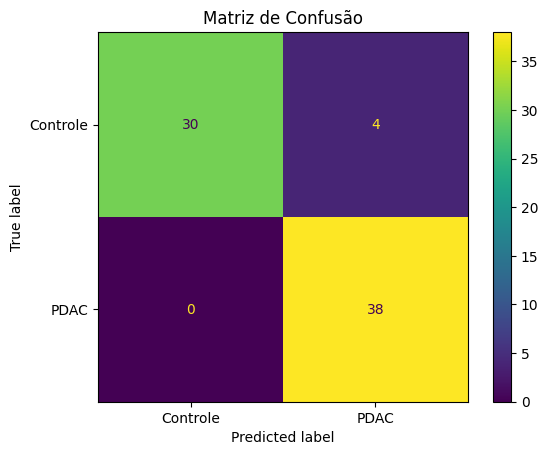

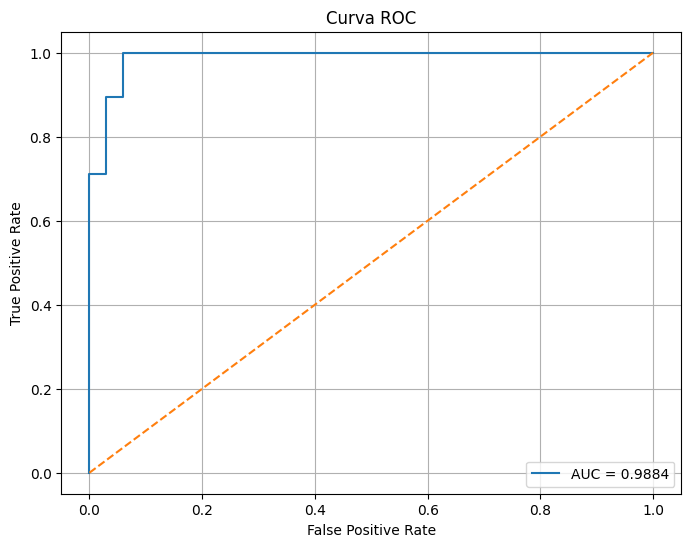

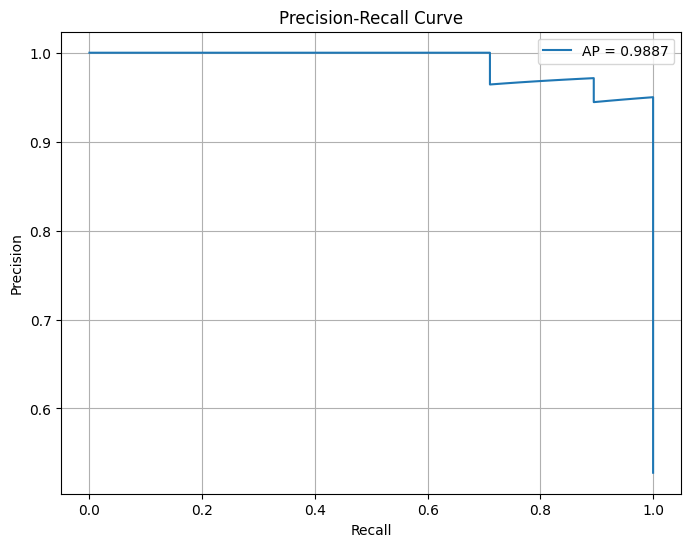

In [36]:
# Matriz de confusao
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Controle", "PDAC"])
disp.plot()

plt.title("Matriz de Confusão")
plt.savefig("plots/Matriz_Confusao.png",dpi=300,bbox_inches="tight")
plt.show()

# Curva Roc
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,label=f"AUC = {auc:.4f}")
plt.plot([0,1],[0,1],linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.grid()

plt.savefig("plots/roc_curve.png",dpi=300,bbox_inches="tight")
plt.show()


# PRECISION-RECALL
plt.figure(figsize=(8,6))
plt.plot(recall,precision,label=f"AP = {ap:.4f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()

plt.savefig("plots/precision_recall_curve.png",dpi=300,bbox_inches="tight")
plt.show()

,miRNA,importance
4,MIMAT0004602,0.379493
20,MIMAT0023700,0.070339
3,MIMAT0004592,0.044252
11,MIMAT0018971,0.042714
26,MIMAT0027498,0.035072
31,MIMAT0027686,0.028493
22,MIMAT0026720,0.028056
23,MIMAT0027359,0.027857
2,MIMAT0003240,0.026864
14,MIMAT0019020,0.024778


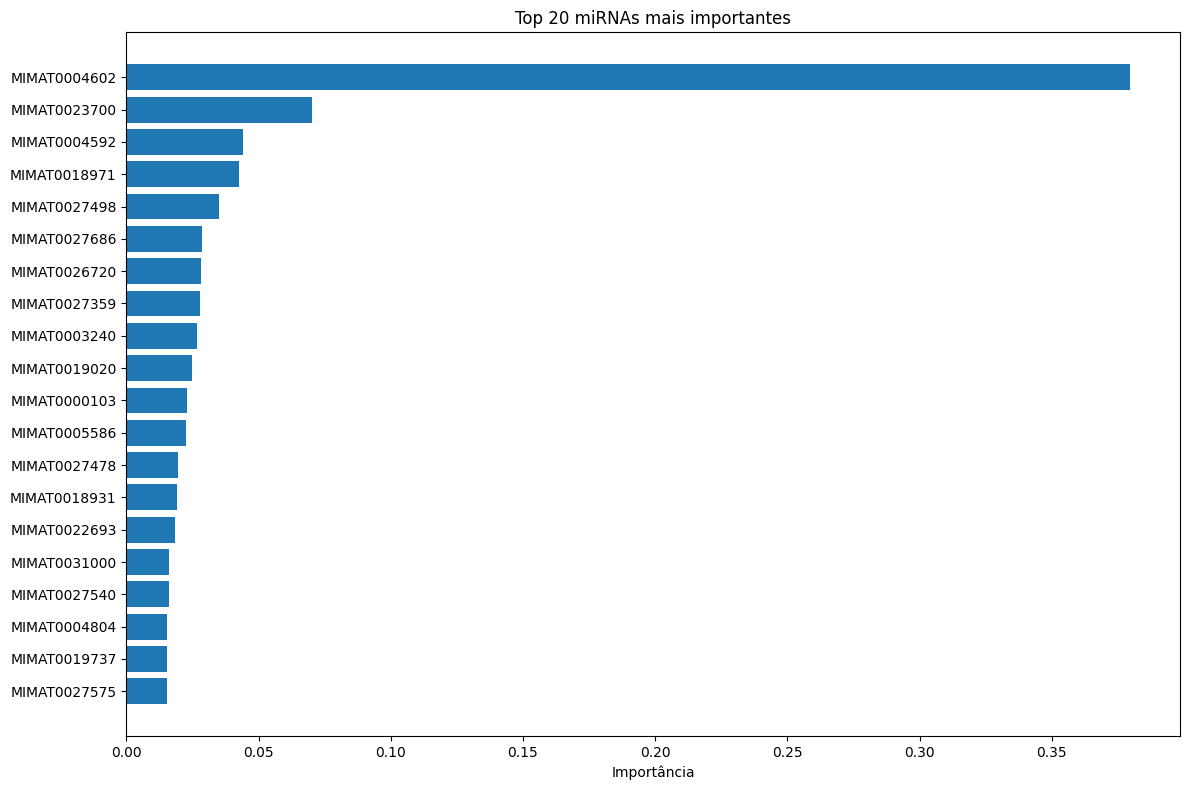

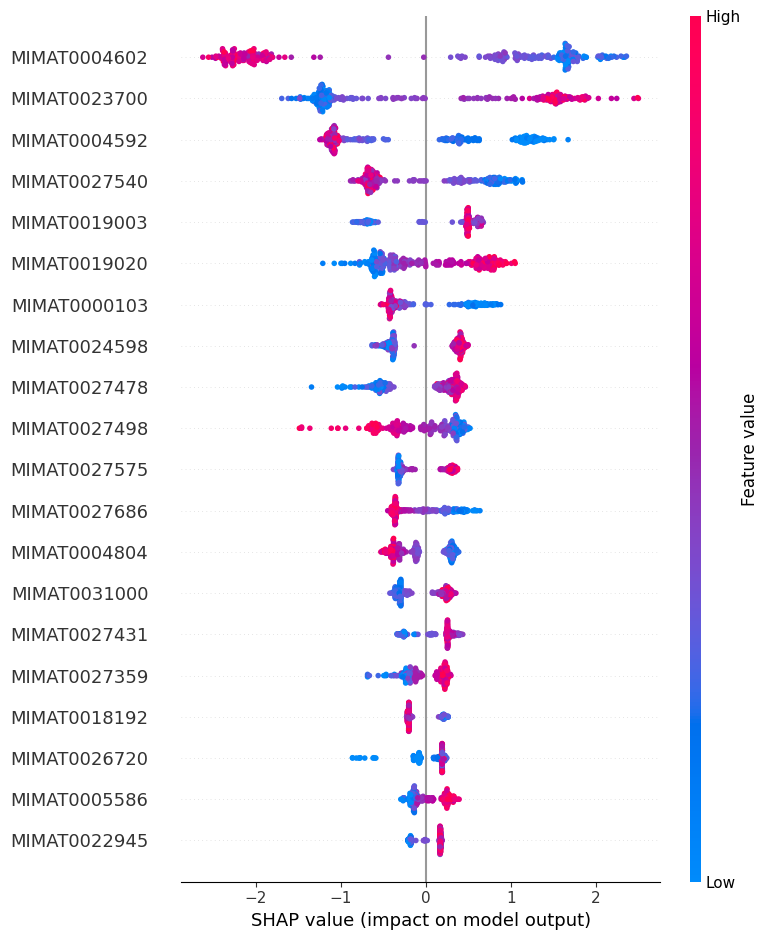

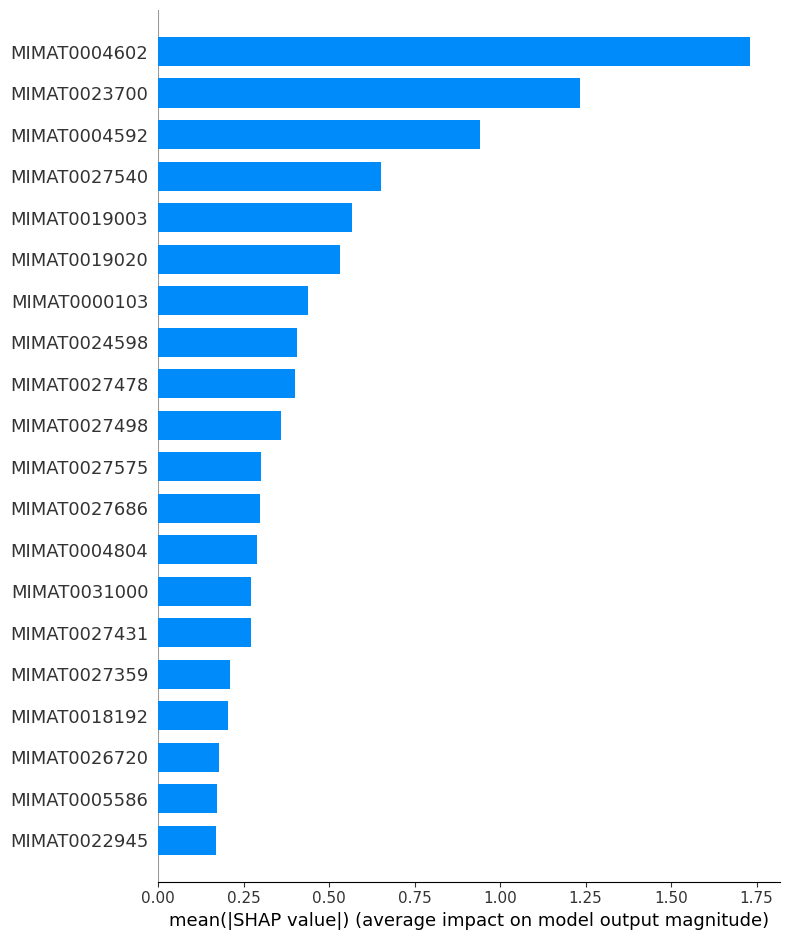

Feature mais importante: MIMAT0004602


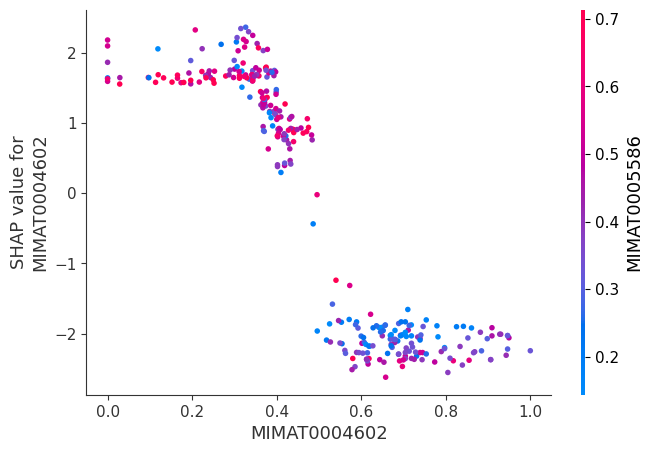

In [37]:
# FEATURE IMPORTANCE (XGBOOST)
importancias = pd.DataFrame({"miRNA": dados_atributos_b.columns,"importance": modelo.feature_importances_})

importancias = importancias.sort_values("importance", ascending=False)

top20 = importancias.head(20)

display(top20)

top20.to_csv("Top20_miRNAs_XGBoost.csv", index=False)


# PLOT FEATURE IMPORTANCE
plt.figure(figsize=(12, 8))
plt.barh(top20["miRNA"], top20["importance"])
plt.gca().invert_yaxis()

plt.title("Top 20 miRNAs mais importantes")
plt.xlabel("Importância")

plt.tight_layout()
plt.savefig("plots/top20_mirnas.png", dpi=300, bbox_inches="tight")
plt.show()


# SHAP
# amostra do dataset de treino (SMOTE output)
X_shap = pd.DataFrame(dados_atributos_b, columns=dados_atributos_b.columns).sample(min(300, len(dados_atributos_b)), random_state=42)

explainer = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_shap)


# SUMMARY PLOT
shap.summary_plot(shap_values, X_shap)

# bar plot
shap.summary_plot(shap_values, X_shap, plot_type="bar")

# DEPENDENCE PLOT
top_feature = top20.iloc[0]["miRNA"]
print(f"Feature mais importante: {top_feature}")

shap.dependence_plot(top_feature, shap_values, X_shap)